<a href="https://colab.research.google.com/github/Nikita11811/DH_Programming_26/blob/main/HW1_Linev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: Предварительная обработка, частоты и морфология в 'Мцыри'

В этом ДЗ вы закрепите навыки из трех тем: предобработка текстов, анализ частот слов и морфологический анализ. Работайте с первыми двумя главами поэмы М.Ю. Лермонтова 'Мцыри'. Выполните базовые задачи, а затем более сложные — с визуализацией и интерпретацией для цифровых гуманитарных исследований. Обработайте и проанализируйте стиль Лермонтова (например, частые глаголы движения для темы 'побега').

**NB! Вы можете использовать свой текст (или полный текст Лермонтова), но тогда вам нужно продумать свою систему исследования, виды глаголов и т.д. Будьте внимательны!**

**Дедлайн: 2.03.2026**

Загрузите результат в любой доступный вам репозиторий и добавьте ссылку в эту таблицу: https://docs.google.com/spreadsheets/d/1C7USVMEkisfqe4l51g_yQX6kbtJYqviPXBIG1c0pc1o/edit?usp=sharing. Если репозиторий закрытый, то зашерьте его на почту a.klimov@hse.ru или aleksklimow@gmail.com. Постарайтесь по возможности оформить работу с файлами так, чтобы это было достаточно легко проверить.

*Не забывайте импортировать библиотеки: `import re`, `import nltk`, `from nltk.corpus import stopwords`, `nltk.download('stopwords')`, `from collections import Counter`, `import matplotlib.pyplot as plt` (для визуализации), `from pymorphy2 import MorphAnalyzer`.*

In [5]:
text = """
Немного лет тому назад,
Там, где, сливаяся, шумят,
Обнявшись, будто две сестры,
Струи Арагвы и Куры,
Был монастырь. Из-за горы
И нынче видит пешеход
Столбы обрушенных ворот,
И башни, и церковный свод;
Но не курится уж под ним
Кадильниц благовонный дым,
Не слышно пенье в поздний час
Молящих иноков за нас.
Теперь один старик седой,
Развалин страж полуживой,
Людьми и смертию забыт,
Сметает пыль с могильных плит,
Которых надпись говорит
О славе прошлой — и о том,
Как, удручен своим венцом,
Такой-то царь, в такой-то год,
Вручал России свой народ.
И божья благодать сошла
На Грузию! Она цвела
С тех пор в тени своих садов,
Не опасаяся врагов,
3а гранью дружеских штыков.
"""  # Краткий текст, полный подгрузите сами, сохранив у себя, например, на гитхабе

In [6]:
import re
import requests
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
!pip install pymorphy3
from pymorphy3 import MorphAnalyzer

nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 66.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Задание 1: Регулярные выражения

1. Напишите регулярное выражение, которое найдет все слова, начинающиеся с "ста".
2. Расширьте: найдите слова с "ста" внутри (не только в начале).
3. Модернизируйте: сделайте 'т' опциональной (замените на любой символ: [а-ят]?).

Ожидаемый вывод: список найденных слов, например, ['старик', 'старый'].

In [7]:
url = "https://raw.githubusercontent.com/Nikita11811/DH_Programming_26/main/Мцыри__Лермонтов_.txt"
response = requests.get(url)
text = response.text
print(text[:200])

Мцыри
автор Михаил Юрьевич Лермонтов (1814—1841)

1

* * *

Немного лет тому назад,

Там, где, сливаяся, шумят,

Обнявшись, будто две сестры,

Струи Арагвы и Куры,

5Был монастырь. Из-за горы

И нынче


In [8]:
reg1 = re.findall(r'\bста\w*\b', text.lower())
print(reg1)

reg2 = re.findall(r'\b\w*ста\w*\b', text.lower())
print(reg2)

reg3 = re.findall(r'\b\w*с[а-ят]?а\w*\b', text.lower())
print(reg3)

['старик', 'стал', 'стал', 'старик', 'старик', 'старик', 'стало', 'стариков', 'старости', 'стало', 'стал', 'стал', 'стал', 'стал', 'стал', 'старик', 'стал', 'стал', 'стало', 'стада', 'стану', 'стану']
['старик', 'остался', 'стал', 'стал', 'привстал', 'остаток', 'старик', 'старик', 'расстаться', 'старик', 'стало', 'стариков', 'старости', 'устав', 'стало', 'стал', 'кустам', 'стал', 'стал', 'простая', 'настаёт', 'стал', 'куста', 'стал', 'старик', 'встал', 'стал', 'остаток', 'стал', 'стало', 'оставила', 'усталую', 'кустах', 'встать', 'хрусталь', 'стада', 'останься', 'усталый', 'остальное', 'стану', 'куста', 'густа', 'стану']
['старик', 'славе', 'садов', 'опасаяся', 'слаб', 'слабый', 'остался', 'спасён', 'сначала', 'стал', 'слаб', 'стал', 'привстал', 'остаток', 'рассказать', 'скалы', 'старик', 'спас', 'сказать', 'старик', 'сладостных', 'расстаться', 'пускай', 'слаб', 'старик', 'скал', 'стало', 'стариков', 'сладостных', 'касалися', 'рассказы', 'старости', 'прекрасна', 'скажи', 'устав', 'сжал

## Задание 2: Нормализация текста

1. Приведите текст к нижнему регистру.
2. Удалите пунктуацию и \n с помощью regex (используйте `re.sub(r'[^а-яё\s]', ' ', text.lower())` как основу).

Сохраните нормализованный текст в `normalized_text`.

In [9]:
normalized_text = text.replace("\n", " ")
normalized_text = re.sub(r'[^а-яё\s]', ' ', text.lower())
#print(normalized_text)

## Задание 3: Токенизация

1. Токенизируйте `normalized_text` на слова (используйте `re.findall(r'\w+', normalized_text)`). Подсчитайте общее число токенов и уникальных (используйте `set` или `Counter`).
2. Токенизируйте оригинальный `text` на строки (`split('\n')`). Сколько строк?
3. Напишите цикл: сохраните слова с заглавной буквы (из оригинального текста).
4. Модернизируйте цикл: исключите первые слова строк (используйте `line.split()` и проверку позиции).

Ожидаемый вывод: len(tokens), len(set(tokens)), список имен/заголовков.

In [10]:
tokens = re.findall(r'\w+', normalized_text)
print(f'Всего токенов: {len(tokens)}')
print(f'Уникальных токенов: {len(set(tokens))}')

Всего токенов: 3446
Уникальных токенов: 1730


In [11]:
lines = text.split('\n')
print(f'Всего строк: {len(lines)}')

Всего строк: 1930


In [12]:
words_capital = []
for word in re.findall(r'\b[А-Я][а-яё]+\b', text):
  words_capital.append(word)
print(words_capital)

['Мцыри', 'Михаил', 'Юрьевич', 'Лермонтов', 'Немного', 'Там', 'Обнявшись', 'Струи', 'Арагвы', 'Куры', 'Из', 'Столбы', 'Но', 'Не', 'Молящих', 'Теперь', 'Развалин', 'Сметает', 'Которых', 'Как', 'Вручал', 'России', 'На', 'Грузию', 'Она', 'За', 'Однажды', 'Из', 'Тифлису', 'Ребёнка', 'Трудов', 'Он', 'Как', 'Развил', 'Его', 'Без', 'Томился', 'Из', 'Из', 'Больного', 'Хранительных', 'Но', 'Сначала', 'Бродил', 'Смотрел', 'По', 'Но', 'Стал', 'Был', 'Уже', 'Изречь', 'Как', 'Осенней', 'Тёмный', 'Три', 'Напрасны', 'Его', 'Болезнь', 'Он', 'Тогда', 'Привстал', 'Ты', 'Сюда', 'Всё', 'Словами', 'Немного', 'Но', 'Одну', 'Изгрызла', 'Она', 'От', 'Где', 'Вскормил', 'Её', 'Старик', 'Что', 'Зачем', 'Угрюм', 'Душой', 'Священных', 'Чтоб', 'От', 'Напрасно', 'Со', 'Не', 'Тогда', 'Мою', 'Прижать', 'Хоть', 'Увы', 'Умру', 'Меня', 'Там', 'Но', 'Знал', 'Разгульной', 'Или', 'Как', 'При', 'Где', 'Дитя', 'Прижавшись', 'Сидит', 'Пускай', 'Что', 'Ты', 'Тебе', 'Ты', 'На', 'Пышные', 'Холмы', 'Дерев', 'Шумящих', 'Когда', 'Мн

In [13]:
words_capital_ultra = []
for line in lines:
  words = line.split()
  for i, word in enumerate(words):
    if i == 0:
      continue
    if re.match(r'\b[А-Я][а-яё]+', word):
      words_capital_ultra.append(word)

print(words_capital_ultra)

['Михаил', 'Юрьевич', 'Лермонтов', 'Арагвы', 'Куры,', 'Из-за', 'России', 'Грузию!', 'Она', 'Тифлису', 'Без', 'Тёмный', 'Угрюм', 'Знал', 'Ты', 'Пышные', 'Кавказ;', 'Жил', 'Много', 'Бледный', 'Хотя', 'Из-под', 'Порой', 'Летние', 'Помню', 'Отрадный', 'Уж', 'Лишь', 'Вдруг', 'Сырую', 'Но', 'Он', 'Туманный', 'Вдали', 'Смутный', 'Чтоб', 'Напрасно', 'Таков', 'Со', 'Едва', 'Мир', 'Лишь', 'Сквозь', 'Арагва', 'Кура,', 'Меня', 'Чешуей', 'Она', 'Божий', 'Безумный', 'Верь', 'Кавказ!', 'Викитеки[1]', 'Вы', 'При', 'Вы']


В последнем блоке все равно встречаются слова, не являющиеся именами собственными или заголовками ("Без", "Она" и т.д), такие слова просто встречаются в середине строки в начале предложения ✍

## Задание 4: Удаление стоп-слов

1. Импортируйте стоп-слова NLTK для русского.
2. Создайте список токенов без стоп-слов (цикл или list comprehension).
3. Подсчитайте оставшиеся токены и уникальные.
4. Добавьте к стоп-словам слова с 'бол' (опциональная 'о': regex `r'\w*б[о]?л\w*'`). Удалите их. Сколько осталось?

Сохраните в `filtered_tokens`.

In [56]:
russian_stopwords = set(stopwords.words('russian'))
print(russian_stopwords)
filtered_tokens = [word for word in tokens if word not in russian_stopwords]

print(f'Осталось токенов: {len(filtered_tokens)}')
print(f'Из них уникальных токенов: {len(set(filtered_tokens))}')

{'чуть', 'им', 'никогда', 'из', 'или', 'вам', 'том', 'ты', 'тогда', 'какая', 'эту', 'себя', 'они', 'без', 'впрочем', 'него', 'ни', 'за', 'для', 'мы', 'еще', 'я', 'ним', 'нее', 'тот', 'них', 'тебя', 'свою', 'теперь', 'разве', 'куда', 'но', 'да', 'можно', 'тут', 'ведь', 'этот', 'почти', 'со', 'после', 'же', 'были', 'не', 'чтоб', 'всех', 'вдруг', 'надо', 'ее', 'чтобы', 'хоть', 'во', 'перед', 'как', 'что', 'между', 'этом', 'то', 'конечно', 'много', 'ей', 'и', 'про', 'ли', 'моя', 'быть', 'нет', 'зачем', 'наконец', 'другой', 'всегда', 'она', 'того', 'всю', 'тоже', 'к', 'опять', 'мне', 'бы', 'два', 'по', 'больше', 'будто', 'даже', 'сейчас', 'было', 'там', 'нельзя', 'у', 'лучше', 'себе', 'только', 'меня', 'его', 'тем', 'от', 'с', 'ж', 'когда', 'совсем', 'мой', 'через', 'он', 'об', 'вы', 'может', 'такой', 'ничего', 'уж', 'вас', 'если', 'более', 'все', 'при', 'нибудь', 'под', 'был', 'чем', 'здесь', 'а', 'потому', 'была', 'нас', 'о', 'есть', 'кто', 'какой', 'чего', 'где', 'ну', 'будет', 'эти', 'и

In [15]:
pat_bol = re.compile(r'\w*б[о]?л\w*')
filtered_tokens = [word for word in filtered_tokens if not pat_bol.match(word)]

print(f'Осталось токенов: {len(filtered_tokens)}')

Осталось токенов: 2197


Мы потеряли более 30 слов, связанных с болью...

## Задание 5: Частотный анализ

1. Используйте `Counter` на `filtered_tokens`: выведите топ-10 самых частых слов.
2. Визуализируйте: Постройте барчарт топ-10 (matplotlib: `plt.bar()`). Подпишите оси ('Слова', 'Частота').
3. Гуманитарная интерпретация: Разделите текст на две главы (используйте индекс поиска 'Глава 2' или вручную). Сравните топ-5 частых слов в каждой (Counter для каждой главы). Что это говорит о темах? (Например, в первой — 'монастырь/плен', во второй — 'свобода/бег').

*Ожидаемый вывод: Таблица сравнения (используйте pandas.DataFrame для топ-5).*

In [52]:
import pandas as pd
from collections import Counter
freq = Counter(filtered_tokens)
top10 = freq.most_common(10)
print(top10)

[('лишь', 12), ('всё', 11), ('мог', 11), ('её', 11), ('грудь', 10), ('мной', 10), ('меж', 10), ('стал', 9), ('долго', 8), ('мою', 8)]


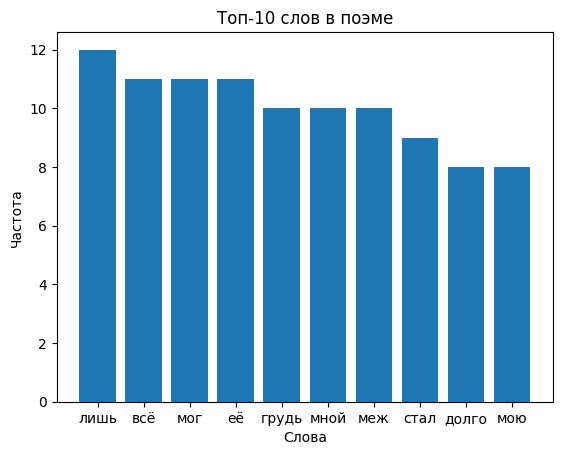

In [53]:
words = [w for w, _ in top10]
freqs = [f for _, f in top10]

plt.figure()
plt.bar(words, freqs)
plt.xlabel('Слова')
plt.ylabel('Частота')
plt.title('Топ-10 слов в поэме')
plt.show()

In [38]:
chapters = text.split("* * *")
chapter1 = chapters[1]
chapter2 = chapters[2]

def normalize_text(chapter):
    normalized = re.sub(r'[^а-яё\s]', ' ', chapter.lower())
    tokens = re.findall(r'\w+', normalized)
    return [word for word in tokens if word not in russian_stopwords]

In [43]:
tokens1 = normalize_text(chapter1)
tokens2 = normalize_text(chapter2)
print(tokens1)

top5_ch1 = Counter(tokens1).most_common(5)
top5_ch2 = Counter(tokens2).most_common(5)

['немного', 'лет', 'тому', 'назад', 'сливаяся', 'шумят', 'обнявшись', 'две', 'сестры', 'струи', 'арагвы', 'куры', 'монастырь', 'горы', 'нынче', 'видит', 'пешеход', 'столбы', 'обрушенных', 'ворот', 'башни', 'церковный', 'свод', 'курится', 'кадильниц', 'благовонный', 'дым', 'слышно', 'пенье', 'поздний', 'час', 'молящих', 'иноков', 'старик', 'седой', 'развалин', 'страж', 'полуживой', 'людьми', 'смертию', 'забыт', 'сметает', 'пыль', 'могильных', 'плит', 'которых', 'надпись', 'говорит', 'славе', 'прошлой', 'удручен', 'своим', 'венцом', 'царь', 'год', 'вручал', 'россии', 'свой', 'народ', 'божья', 'благодать', 'сошла', 'грузию', 'цвела', 'тех', 'пор', 'тени', 'своих', 'садов', 'опасаяся', 'врагов', 'гранью', 'дружеских', 'штыков']


In [48]:
df1 = pd.DataFrame({
    "Глава 1 (слово)": [w for w, _ in top5_ch1],
    "Глава 1 (частота)": [f for _, f in top5_ch1]
})

df2 = pd.DataFrame({
    "Глава 2 (слово)": [w for w, _ in top5_ch2],
    "Глава 2 (частота)": [f for _, f in top5_ch2]
})

In [49]:
df1

,Глава 1 (слово),Глава 1 (частота)
0,немного,1
1,лет,1
2,тому,1
3,назад,1
4,сливаяся,1


In [50]:
df2

,Глава 2 (слово),Глава 2 (частота)
0,однажды,2
1,гор,2
2,лет,2
3,слаб,2
4,гордо,2


Анализ вышел нерепрезентативный, т.к. главы в этой поэме сильно небольшого размера, и в первой, например, слова (оставшиеся после очистки текста) встречаются по одному разу, поэтому в дата фрейме они представлены как раз в порядке появления в тексте друг за дружкой, но пусть будет как есть! 🔬

А глубокую гуманитарную интерпретацию оставим для анализа самых частотных слов по томам "Войны и мира" ✅

## Задание 6: Морфологический анализ

1. Инициализируйте `MorphAnalyzer` из pymorphy2. Проанализируйте POS (часть речи) для топ-10 частых слов из Задания 5 (`.tag.POS` или `.parse(word)[0].tag.POS`).
2. Создайте Counter для частей речи во всем `filtered_tokens` (цикл: для каждого токена — morph.parse(word)[0].tag.POS). Выведите топ-3 (существительные? глаголы?).
3. Найдите все глаголы движения ('бежать', 'мчаться' и т.п. — используйте regex `r'\b[бмп]е[жз]у?\w*'`) и их формы (morph.normal_form). Сколько уникальных лемм? Как это отражает тему 'побега' в 'Мцыри'?

*Ожидаемый вывод: Словарь {POS: count}, список лемм глаголов.*

In [55]:
morph = MorphAnalyzer()

for word, freq in top10:
    parsed = morph.parse(word)[0]
    pos = parsed.tag.POS
    print(f"{word} -> {pos}")

лишь -> PRCL
всё -> PRCL
мог -> VERB
её -> ADJF
грудь -> NOUN
мной -> NPRO
меж -> PREP
стал -> VERB
долго -> ADVB
мою -> ADJF


In [59]:
pos_counter = Counter()

for word in filtered_tokens:
  pos = morph.parse(word)[0].tag.POS
  pos_counter[pos] += 1

print(pos_counter.most_common(3))

[('NOUN', 930), ('ADJF', 417), ('VERB', 414)]


Видим, что существительных в тексте больше, чем глаголов и прилагательных вместе взятых, о чем это говорит? Много номинативных предложений в тексте (описывается природа, пространство, люди и тд), при этом самого действия не так много

In [73]:
pattern = re.compile(r'\b[бмп]е[жз]у?\w*')
# но такая регулярка выцепит только глаголы с корнем "бег", всякие "мчаться" и остальные туда не попадут

pattern = re.compile(r'\b(беж\w*|мч\w*|полз\w*|ид\w*|брос\w*)')
# поэтому попробуем хотя бы такую с несколькими корневыми вариантами

In [75]:
running_verbs = []
running_lemmas = set()

for word in filtered_tokens:
  if pattern.match(word):
    if morph.parse(word)[0].tag.POS in ["VERB", 'INFN']:
      running_verbs.append(word)
      running_lemmas.add(morph.parse(word)[0].normal_form)

print(running_verbs)
print(running_lemmas)

['бежал', 'бежал', 'бежал', 'полз', 'бежали']
{'ползти', 'бежать'}


Все равно у нас только две леммы попадают cюда :/

Кстати, прикол, ни одного слова во всем тексте с леммой 'идти'! (из тех, что без приставки, разумеется)

Поэтому, если мы хотим отследить тему побега в поэме, надо попробовать подойти к этому как-то по другому, например выделить вообще все встречающиеся глаголы и поискать среди самых популярных с семантикой движения.

In [76]:
# например, что-то подобное
verb_lemmas = []

for word in filtered_tokens:
  if morph.parse(word)[0].tag.POS in ["VERB", 'INFN']:
    verb_lemmas.append(morph.parse(word)[0].normal_form)

verb_counter = Counter(verb_lemmas)
top_verbs = verb_counter.most_common(10)
print(top_verbs)


[('стать', 14), ('мочь', 14), ('жить', 12), ('знать', 11), ('видеть', 10), ('казаться', 7), ('хотеть', 6), ('бежать', 6), ('говорить', 5), ('помнить', 5)]


В общем и целом, ладно, глаголов движения тут не особо много, в топе только 'бежать', зато по самым популярным глагольным леммам мы лишний раз увидели, почему это романтическая поэма о поиске места лирического героя в мире и обществе ⛪

## Задание 7: Интеграция и интерпретация

1. Соберите пайплайн: Обработайте полный текст (объедините главы), создайте 'чистый' корпус (нормализация + фильтрация + лемматизация с pymorphy2). В этом случае можно использовать нестандартные решения, которые мы изучали бегло или только упоминали.
2. Сравнительный анализ: Вычислите TF-IDF для двух глав (используйте простой расчет: freq_in_doc / log(total_docs / docs_with_word)). Выведите топ-3 уникальных слова для каждой главы.
3. Визуализация стиля: Постройте word cloud. Сравните облака для глав.
4. Вывод: В 100–200 словах опишите, как обработка раскрывает романтизм Лермонтова (контраст 'плена' и 'свободы').

Предлагаю в след раз при всей любви к Лермонтову анализировать произведения, в которых хотя бы не по несколько строчек в каждой главе, чтобы получались более-менее релевантные результаты 🙏

In [82]:
# окей сделаем это заново - текст лежит в переменной text (как ни странно)

normalized = re.sub(r'[^а-яё\s]', ' ', text.lower())

tokens = re.findall(r'\w+', normalized)

filtered = [morph.parse(word)[0].normal_form for word in tokens if word not in russian_stopwords]

In [90]:
# теперь сделаем это по главам для подсчета TF-IDF

def prepare_doc(text):
    normalized = re.sub(r'[^а-яё\s]', ' ', text.lower())
    tokens = re.findall(r'\w+', normalized)

    return [
        morph.parse(word)[0].normal_form
        for word in tokens
        if word not in russian_stopwords
    ]

doc1 = prepare_doc(chapter1)
doc2 = prepare_doc(chapter2)

doc_full = prepare_doc(text) # это я для всего текста посчитать потом хочу

In [84]:
import math

def tfidf_score(word, doc, docs):
    freq = doc.count(word)

    if freq == 0:
        return 0

    total_docs = len(docs)

    docs_with_word = sum(1 for d in docs if word in d)

    return freq / math.log((total_docs / (docs_with_word + 1)) + 1)

In [87]:
docs = [doc1, doc2]

unique_words = set(doc1).union(set(doc2))

tfidf_doc1 = {w: tfidf_score(w, doc1, docs) for w in unique_words}
tfidf_doc2 = {w: tfidf_score(w, doc2, docs) for w in unique_words}

top3_doc1 = sorted(tfidf_doc1.items(), key=lambda x: x[1], reverse=True)[:3]
top3_doc2 = sorted(tfidf_doc2.items(), key=lambda x: x[1], reverse=True)[:3]

print(f'Топ-3 уникальных слова (Глава 1): {top3_doc1}')
print(f'Топ-3 уникальных слова (Глава 2): {top3_doc2}')

Топ-3 уникальных слова (Глава 1): [('свой', 5.872845566913654), ('год', 3.915230377942436), ('тот', 2.8853900817779268)]
Топ-3 уникальных слова (Глава 2): [('гора', 5.872845566913654), ('слабый', 4.328085122666891), ('год', 3.915230377942436)]


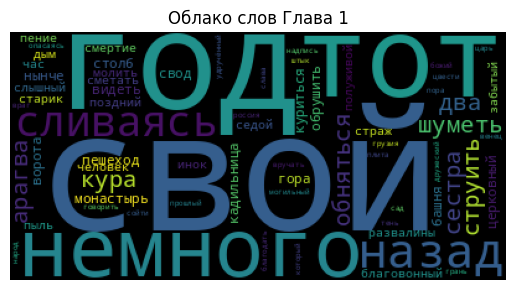

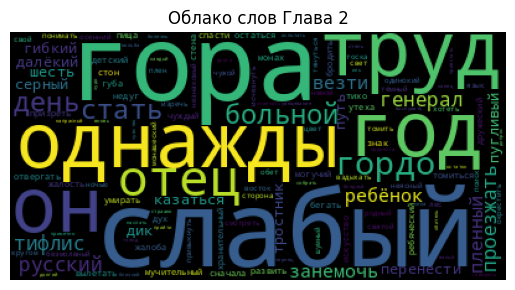

In [89]:
from wordcloud import WordCloud

text_for_cloud1 = " ".join(doc1)
text_for_cloud2 = " ".join(doc2)

plt.figure()
WordCloud(width=800, height=400).generate(text_for_cloud1)
plt.title("Облако слов Глава 1")
plt.imshow(WordCloud().generate(text_for_cloud1))
plt.axis("off")
plt.show()

plt.figure()
plt.title("Облако слов Глава 2")
plt.imshow(WordCloud().generate(text_for_cloud2))
plt.axis("off")
plt.show()

Такой обработкой мы не особо раскроем романтизм Лермонтова по вышеописанным причинам. И вообще, слово "свой", например, точно должно было улететь в помоечку на этапе фильтрации стоп-слов, но допустим. Я все-таки попробую получить облако слов для всего текста полностью, посмотрим, что там будет.

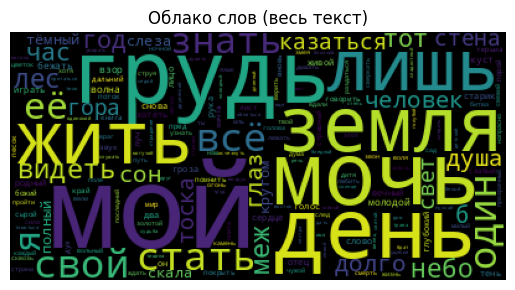

In [94]:
text_for_cloud_full = " ".join(doc_full)

plt.figure()
WordCloud(width=800, height=400).generate(text_for_cloud_full)
plt.title("Облако слов (весь текст)")
plt.imshow(WordCloud().generate(text_for_cloud_full))
plt.axis("off")
plt.show()


Почему лемма "мой" не считается стоп-словом?????

Я проверил, считается, но по какой-то причине не отфильтровалась, вопросы к качеству исходного текста, возможно. В принципе, в последнем облаке слов есть объективно полезные леммы для нас в контексте анализа романтизма (жить, мочь, один, душа, свой, стать, небо, свет - такие базированные для данного стиля слова)

To sum up, не будем придумывать из мухи слона, скажем лишь, что в списке самых частотных слов есть некоторые ключевые как для данной поэмы, так и для творчества Лермонтова generally ("ГОРА"), ну хорошо, еще есть прилагательное "слабый", которое лучше всего характеризует как конкретного лирического героя поэмы, так и в целом классического романтического персонажа (почувствовали каламбур, да?), поэтому определенные выводы можем сформулировать, но весьма поверхностно, на мой взгляд.